# はじめてのイベント駆動バックテスト

セクション02のバックテストはベクトル化された形式です。日付ごとにシグナルを計算し、その後に
実現したリターンを掛けて、合計します。月次リバランスならこれが正しい道具ですが、誰も提示して
いない価格で売買したことが、そっと前提に紛れ込んでいます。

イベント駆動バックテストはその前提を外します。注文はある瞬間に出され、その瞬間に記録されていた
板にぶつかり、約定したかどうか、いくらで約定したか、手数料と遅延はどれだけかをエンジンが決めます。
実行コストは高くつきます。それでも、戦略が自分自身の執行に耐えるかを問える方法はこれだけです。

このレシピでは、時刻のついた注文意図を、監査できるシミュレーションに変えます。マーケットデータは
戦略を書く前にピン留めします。注文、約定、ポジション、エクイティは、隔離されたフォーク上の
ふつうのバージョン管理されたテーブルになります。

## ここで使う用語

| 用語 | 意味 |
| --- | --- |
| イベント駆動バックテスト | バーの価格ではなく、記録されたマーケットデータに1イベントずつ注文をぶつける形式 |
| シグナル | ここでは注文意図。何を、どちら向きに、どれだけ、いつ売買するか |
| 約定（fill） | 自分の注文に対する約定。仮定ではなくエンジンが生む |
| ポジション | ある銘柄について持っている数量と、その取得原価 |
| エクイティカーブ | 口座価値の累積推移 |
| 実行フォーク | 実行が結果を書き込む、隔離されたデータベースの枝。実行どうしがぶつからない |
| ピン留め | 戦略を書く前に、その実行のマーケットデータを特定のスナップショットに固定すること |

はじめて見る用語があれば、[GLOSSARY.ja.md](../../GLOSSARY.ja.md) にもう少し詳しい説明があります。ほかのレシピで使う用語もまとめてあります。

フィクスチャには、参照データ、アトミックな L2 スナップショット、そして1つの予測市場のプリントが
入っています。板の1行は、ある `event_index` の中の1つの価格帯です。`is_last` がアトミックな
イベントの境界を示します。

| テーブル | 行数 | 時刻列 | 用途 |
|---|---:|---|---|
| `instruments` | 2 | `ts_init` | 取引所のルールと結果のメタデータ |
| `book_deltas` | 360 | `ts_init` | マッチングに使うビッド／アスクのスナップショット |
| `trades` | 180 | `ts_init` | キューを考慮した約定モデルが使うプリント |

In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import pyarrow as pa

import h5i_db
from h5i_db import backtest
import cookbook_utils as cu

fixture = cu.make_backtest_fixture(steps=180)
for name, table in fixture.items():
    print(f"{name}: {table.num_rows:,} rows x {table.num_columns} columns")
fixture["book_deltas"].to_pandas().head()

instruments: 2 rows x 10 columns
book_deltas: 360 rows x 11 columns
trades: 180 rows x 9 columns


,ts_init,ts_event,instrument_id,outcome,action,side,price,size,event_index,is_last,source_vendor
0,2026-06-01 14:00:01,2026-06-01 14:00:01,RATE-CUT-YES,0,snapshot,buy,0.4766,90.0,1,False,cookbook-sim
1,2026-06-01 14:00:01,2026-06-01 14:00:01,RATE-CUT-YES,0,snapshot,sell,0.4866,90.0,1,True,cookbook-sim
2,2026-06-01 14:00:02,2026-06-01 14:00:02,RATE-CUT-YES,0,snapshot,buy,0.4783,100.0,2,False,cookbook-sim
3,2026-06-01 14:00:02,2026-06-01 14:00:02,RATE-CUT-YES,0,snapshot,sell,0.4883,100.0,2,True,cookbook-sim
4,2026-06-01 14:00:03,2026-06-01 14:00:03,RATE-CUT-YES,0,snapshot,buy,0.4799,110.0,3,False,cookbook-sim


正規のスキーマはイベント時刻と到着時刻を区別します。この例では両者を同じにしてあります。リプレイの
順序は `ts_init` に従うので、本番のローダはフィードが両方を出すなら両方とも残してください。

In [2]:
fixture["book_deltas"].schema

ts_init: timestamp[ns] not null
ts_event: timestamp[ns] not null
instrument_id: string not null
outcome: uint16 not null
action: string not null
side: string
price: double
size: double
event_index: int64 not null
is_last: bool not null
source_vendor: string

イベント種別ごとに、時刻でインデックスされたテーブルを1つ作ります。名前付きスナップショットは、
このレシピのすべての実行が使う、動かないマーケットデータの断面です。

In [3]:
db = h5i_db.Database(cu.fresh_db("04_first_event_driven_run"), create=True)
for name, table in fixture.items():
    db.create_table(name, table.schema, time_column="ts_init")
    db.append(name, table, note="deterministic cookbook fixture")
db.snapshot(
    "market-cut-2026-06-01",
    tables=["instruments", "book_deltas", "trades"],
    note="Approved input for the first event-driven run",
)
db.tables()

['book_deltas', 'instruments', 'trades']

signals テーブルが戦略の境界です。各行は意図を述べるだけで、約定ではありません。実際に執行できる
価格は、マーケットデータ、手数料、レイテンシ、約定ルールを当てはめたうえでエンジンが決めます。

| 列 | 型 | 意味 |
|---|---|---|
| `ts` | `timestamp[ns]` | 戦略の境界に到着する最も早い時刻 |
| `instrument_id` | `string` | 売買する銘柄 |
| `side` | `string` | `buy` または `sell` |
| `quantity` | `float64` | 要求する数量 |
| `kind` | `string` | `market` または `limit` |
| `tag` | `string` | 約定まで引き継がれる、安定した調査用ラベル |

In [4]:
base = dt.datetime(2026, 6, 1, 14, 0, 0)
signals = backtest.signal_table(
    [
        {
            "ts": base + dt.timedelta(seconds=20),
            "instrument_id": "RATE-CUT-YES",
            "side": "buy",
            "quantity": 50.0,
            "tag": "open",
        },
        {
            "ts": base + dt.timedelta(seconds=120),
            "instrument_id": "RATE-CUT-YES",
            "side": "sell",
            "quantity": 50.0,
            "tag": "close",
        },
    ]
)
print(f"{signals.num_rows:,} rows x {signals.num_columns} columns")
signals.to_pandas()

2 rows x 10 columns


,ts,instrument_id,outcome,side,quantity,kind,limit_price,time_in_force,tag,reduce_only
0,2026-06-01 14:00:20,RATE-CUT-YES,0,buy,50.0,market,NaN,NaN,open,False
1,2026-06-01 14:02:00,RATE-CUT-YES,0,sell,50.0,market,NaN,NaN,close,False


戦略はマーケットのスナップショットを取ったあとに保存します。シグナルはマーケットデータのピンとは
別にバージョン管理されるので、あとから作った調査でも、当時から存在したふりをせずに、承認済みの
過去の断面をリプレイできます。

In [5]:
backtest.create_signal_table(db)
db.append("signals", signals, note="two-leg demonstration strategy")

{'table': 'signals',
 'sequence': 1,
 'op': 'append',
 'rows_total': 2,
 'segments_total': 1,
 'segments_added': 1,
 'segments_deduped': 0,
 'committed_at_ns': 1785437756715738231}

手数料モデルとエクイティのサンプリング間隔を明示して実行します。実行が書き込むのは
`bt-first-run` だけで、元のデータベースは変わりません。

In [6]:
report = backtest.run(
    db,
    "first-run",
    starting_cash=10_000.0,
    signals="signals",
    snapshot="market-cut-2026-06-01",
    fee_rate=0.02,
    equity_interval_nanos=5_000_000_000,
)
report

{'run_id': 'first-run',
 'fork': 'bt-first-run',
 'digest': '05b50c3deb55c74bbda930f0d2abb61d8f003b8642c59b98d908f7b0e1e7317f',
 'starting_cash': 10000.0,
 'final_cash': 10000.5410324,
 'realized_pnl': 0.5410324,
 'commissions': 0.4989676,
 'funding_paid': 0.0,
 'fills': 2,
 'orders': 2,
 'records_processed': 360,
 'simulated_through_ns': 1780322580000000000,
 'equity_points': 37,
 'settlement_applied': False,
 'coverage': None,
 'liquidations': 0,
 'rejected_for_margin': 0,
 'self_trades_prevented': 0,
 'metrics': {'orders_submitted': 2,
  'orders_filled': 2,
  'orders_cancelled_unfilled': 0,
  'orders_rejected_margin': 0,
  'orders_rejected_risk': 0,
  'orders_rejected_self_trade': 0,
  'fills_taker': 2,
  'fills_maker': 0,
  'book_gaps': 0,
  'liquidations': 0},
 'warnings': []}

レポートはコンパクトな実行マニフェストです。詳しい監査証跡はフォークの中にあります。`bt_fills` が
正本で、ポジションはそこからいつでも再構成できます。

In [7]:
run_db = db.fork(report["fork"])
fills = run_db.read("bt_fills").to_pandas()
orders = run_db.read("bt_orders").to_pandas()
positions = run_db.read("bt_positions").to_pandas()
print(orders[["order_id", "side", "quantity", "filled", "status", "tag"]])
fills

   order_id  side  quantity  filled  status    tag
0         1   buy      50.0    50.0  filled   open
1         2  sell      50.0    50.0  filled  close


,ts,order_id,instrument_id,outcome,side,price,quantity,commission,is_taker,tag
0,2026-06-01 14:00:20,1,RATE-CUT-YES,0,buy,0.5098,50.0,0.249904,True,open
1,2026-06-01 14:02:00,2,RATE-CUT-YES,0,sell,0.5306,50.0,0.249064,True,close


パフォーマンスを分析する前に、まず前提が満たされているかを検証します。タグのついた2つの注文は
どちらも約定していなければならず、決済側の注文はネットのエクスポージャを残していてはいけません。

In [8]:
assert report["fills"] == 2
assert fills["tag"].tolist() == ["open", "close"]
assert positions.empty or abs(positions["quantity"].sum()) < 1e-9
print(f"digest={report['digest']}")
print(f"commissions={report['commissions']:.6f}")
print(f"realized P&L={report['realized_pnl']:.6f}")

digest=05b50c3deb55c74bbda930f0d2abb61d8f003b8642c59b98d908f7b0e1e7317f
commissions=0.498968
realized P&L=0.541032


エクイティは入力行ごとではなく、シミュレーション上の時刻でサンプリングされます。これでティック
データでも出力の大きさが抑えられ、リスク系列としての有用性は保たれます。

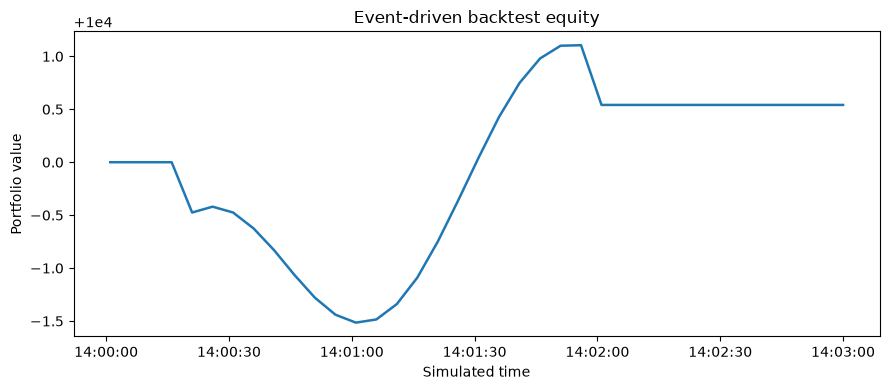

In [9]:
equity = run_db.read("bt_equity").to_pandas()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(equity["ts"], equity["equity"], linewidth=1.8)
ax.set_title("Event-driven backtest equity")
ax.set_xlabel("Simulated time")
ax.set_ylabel("Portfolio value")
fig.tight_layout()

## まとめ

- 戦略とは、注文意図をバージョン管理したテーブルである。
- 名前付きスナップショットが、その実行のマーケットデータ入力をすべて固定する。
- マッチング、手数料、ポートフォリオ会計は、1つの決定的なカーネルの中で起きる。
- 実行の出力は、隔離されたフォーク上でクエリできる `bt_*` テーブルになる。
- ダイジェストとソースのピンが、結果を再現するのに要る最小限の証拠を与える。

In [10]:
run_db.close()
db.close()